<a href="https://colab.research.google.com/github/asternoeld/practical-ml-25-26/blob/main/notebooks/spanish_white_wine_high_ratings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data preparation

## Download data

In [47]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fedesoriano/spanish-wine-quality-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'spanish-wine-quality-dataset' dataset.
Path to dataset files: /kaggle/input/spanish-wine-quality-dataset


In [48]:
import os
import pandas as pd

# List files in the downloaded dataset directory
files = os.listdir(path)
print("Files in the dataset directory:", files)

Files in the dataset directory: ['wines_SPA.csv']


In [49]:
df = pd.read_csv(csv_file_path)

# CREATE TARGET HERE
df['binary_rating'] = (df['rating'] >= 4.5).astype(int)

## Read data to dataframe

In [50]:
# Assuming the CSV file is named 'wines_SPA.csv' based on typical Kaggle dataset structures
csv_file_path = os.path.join(path, 'wines_SPA.csv')

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(csv_file_path)

# Display the first 5 rows of the DataFrame
display(df.head())

,winery,wine,year,rating,num_reviews,country,region,price,type,body,acidity
0,Teso La Monja,Tinto,2013,4.9,58,Espana,Toro,995.00,Toro Red,5.0,3.0
1,Artadi,Vina El Pison,2018,4.9,31,Espana,Vino de Espana,313.50,Tempranillo,4.0,2.0
2,Vega Sicilia,Unico,2009,4.8,1793,Espana,Ribera del Duero,324.95,Ribera Del Duero Red,5.0,3.0
3,Vega Sicilia,Unico,1999,4.8,1705,Espana,Ribera del Duero,692.96,Ribera Del Duero Red,5.0,3.0
4,Vega Sicilia,Unico,1996,4.8,1309,Espana,Ribera del Duero,778.06,Ribera Del Duero Red,5.0,3.0


## Organize data

**Prompt 1**: organize original data; the response variable should be binary (0 if rating lower than 4.2), all other variables should be converted into numeric; remove variable 'wine' and 'winery'

**Prompt 2**: I don't want year to be categorical. Convert year information into a new variable that indicates how old is the wine (using 2026 as reference year).

### Variable selection and one-hot encoding

In [51]:
import numpy as np
import pandas as pd
import os

# Reload the original DataFrame to ensure we start from a clean state
# Assuming csv_file_path is still available from previous steps
if 'csv_file_path' in locals() and os.path.exists(csv_file_path):
    df = pd.read_csv(csv_file_path)
else:
    print("Error: csv_file_path not found or file does not exist. Please ensure the data loading step ran correctly.")

print(f"Original DataFrame shape: {df.shape}")

# 1. Remove 'wine' and 'winery' variables
columns_to_drop = ['wine', 'winery']
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])
print(f"DataFrame shape after dropping 'wine' and 'winery': {df.shape}")

# 2. Create the binary response variable 'binary_rating'
df['binary_rating'] = (df['rating'] >= 4.5).astype(int)

# 3. Convert 'price' to numeric
if 'price' in df.columns and df['price'].dtype == 'object':
    df['price'] = df['price'].astype(str).str.replace('€', '', regex=False).str.replace(',', '', regex=False)
    df['price'] = pd.to_numeric(df['price'], errors='coerce')
    # Fill NaN values in 'price' after conversion, e.g., with the mean or median
    df['price'].fillna(df['price'].mean(), inplace=True)

# 4. Convert 'year' to numeric and create 'wine_age'
# Handle 'year' column before identifying other categorical columns
if 'year' in df.columns:
    # Convert 'year' to numeric, coercing errors to NaN
    df['year'] = pd.to_numeric(df['year'], errors='coerce')
    # Fill any NaN values in 'year' that might result from coercion, e.g., with the median or mode
    df['year'].fillna(df['year'].median(), inplace=True)
    df['year'] = df['year'].astype(int) # Convert to int after filling NaNs

    # Create 'wine_age' using 2026 as reference year
    df['wine_age'] = 2026 - df['year']
    df = df.drop('year', axis=1) # Drop the original 'year' column

# 5. Identify *remaining* categorical columns for one-hot encoding
# Exclude 'rating' (original, to be dropped) and 'binary_rating' (new target)
# The 'year' column has already been handled and dropped if it existed
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# 6. Apply one-hot encoding to remaining categorical columns
if categorical_cols:
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# 7. Drop the original 'rating' column as 'binary_rating' is the new target
df = df.drop('rating', axis=1)

# Display the first few rows and information of the processed DataFrame
display(df.head())
df.info()

Original DataFrame shape: (7500, 11)
DataFrame shape after dropping 'wine' and 'winery': (7500, 9)


/tmp/ipykernel_6402/2298520980.py:35: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['year'].fillna(df['year'].median(), inplace=True)


,num_reviews,price,body,acidity,binary_rating,wine_age,region_Alella,region_Alicante,region_Almansa,region_Andalucia,...,type_Ribera Del Duero Red,type_Rioja Red,type_Rioja White,type_Sauvignon Blanc,type_Sherry,type_Sparkling,type_Syrah,type_Tempranillo,type_Toro Red,type_Verdejo
0,58,995.00,5.0,3.0,1,13,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,31,313.50,4.0,2.0,1,8,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,1793,324.95,5.0,3.0,1,17,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
3,1705,692.96,5.0,3.0,1,27,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
4,1309,778.06,5.0,3.0,1,30,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Columns: 101 entries, num_reviews to type_Verdejo
dtypes: bool(95), float64(3), int64(3)
memory usage: 1.0 MB


### Select white wines

**Prompt**: Sure, I can help you filter the DataFrame to include only white wines. I'll select rows where the 'type' contains 'White', 'Blanc', or 'Verdejo' from the one-hot encoded columns. Remove columns that are constant

In [52]:
white_wine_columns = [
    col for col in df.columns if 'White' in col or 'Blanc' in col or 'Verdejo' in col
]

# Filter the DataFrame to include only white wines
# We assume a wine is 'white' if any of the identified white wine type columns are True
df_white_wines = df[df[white_wine_columns].any(axis=1)]

print(f"Original DataFrame shape: {df.shape}")
print(f"Shape of DataFrame with only white wines: {df_white_wines.shape}")
display(df_white_wines.head())

Original DataFrame shape: (7500, 101)
Shape of DataFrame with only white wines: (123, 101)


,num_reviews,price,body,acidity,binary_rating,wine_age,region_Alella,region_Alicante,region_Almansa,region_Andalucia,...,type_Ribera Del Duero Red,type_Rioja Red,type_Rioja White,type_Sauvignon Blanc,type_Sherry,type_Sparkling,type_Syrah,type_Tempranillo,type_Toro Red,type_Verdejo
73,425,795.00,3.0,3.0,1,40,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
245,107,50.51,3.0,3.0,1,8,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
323,33,75.95,3.0,3.0,1,10,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
380,1192,32.85,3.0,3.0,1,8,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
388,961,37.70,3.0,3.0,1,7,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [53]:
print(f"Shape before removing constant columns: {df_white_wines.shape}")

# Identify constant columns
constant_columns = [col for col in df_white_wines.columns if df_white_wines[col].nunique() == 1]

# Drop constant columns
df_white_wines = df_white_wines.drop(columns=constant_columns)

print(f"Shape after removing constant columns: {df_white_wines.shape}")
display(df_white_wines.head())

Shape before removing constant columns: (123, 101)
Shape after removing constant columns: (123, 15)


,num_reviews,price,binary_rating,wine_age,region_Castilla y Leon,region_Penedes,region_Ribera del Duero,region_Rioja,region_Rioja Alta,region_Rueda,region_Toro,region_Vino de Espana,type_Rioja White,type_Sauvignon Blanc,type_Verdejo
73,425,795.00,1,40,False,False,False,True,False,False,False,False,True,False,False
245,107,50.51,1,8,True,False,False,False,False,False,False,False,False,False,True
323,33,75.95,1,10,False,False,False,False,False,False,False,True,False,False,True
380,1192,32.85,1,8,False,False,False,False,False,True,False,False,False,False,True
388,961,37.70,1,7,False,False,False,False,False,True,False,False,False,False,True


In [54]:
print(df_white_wines.columns)

Index(['num_reviews', 'price', 'binary_rating', 'wine_age',
       'region_Castilla y Leon', 'region_Penedes', 'region_Ribera del Duero',
       'region_Rioja', 'region_Rioja Alta', 'region_Rueda', 'region_Toro',
       'region_Vino de Espana', 'type_Rioja White', 'type_Sauvignon Blanc',
       'type_Verdejo'],
      dtype='object')


### Define response variable and predictor arrays

**Prompt**: Create variables y (binary rating) and X (other variables). I also want to reserve 20% of the data for testing.

In [55]:
from sklearn.model_selection import train_test_split

# Define the target variable (y) and features (X)
y = df_white_wines['binary_rating']
X = df_white_wines.drop('binary_rating', axis=1)

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (98, 14)
Shape of X_test: (25, 14)
Shape of y_train: (98,)
Shape of y_test: (25,)


# Processing

Build pre-processing+processing pipeline:

- Use standard scaler for continuous variables ('num_reviews', 'price', 'wine_age') and do not transform binary variables
- Use a logistic regression for the prediction model


# Evaluating prediction model performance


## Compute accuracy metrics

- Use test data set to evaluate model performance
- Create Classification Report
- How would you generalize performance evaluation to a prediction model with more than 2 output labels, say, 'regular wines', 'medium wines'. 'top wines'?

## Explore thresholds

- Create precision-recal curve
- Create ROC curve

# Discussion

- What is the best threshold to use for the predictive model?
- How should the pipeline be adapted to include the selection of the threshold?

In [56]:
print(y_train.value_counts())
print(y_test.value_counts())

binary_rating
0    88
1    10
Name: count, dtype: int64
binary_rating
0    22
1     3
Name: count, dtype: int64


In [58]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Define columns
num_cols = ['num_reviews', 'price', 'wine_age']
bin_cols = [col for col in X_train.columns if col not in num_cols]

# Preprocessing
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('bin', 'passthrough', bin_cols)
])

# Pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression())
])

In [59]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['num_reviews', 'price',
                                                   'wine_age']),
                                                 ('bin', 'passthrough',
                                                  ['region_Castilla y Leon',
                                                   'region_Penedes',
                                                   'region_Ribera del Duero',
                                                   'region_Rioja',
                                                   'region_Rioja Alta',
                                                   'region_Rueda',
                                                   'region_Toro',
                                                   'region_Vino de Espana',
                                                   'type_Rioja White',
                                                   'type_Sauvignon Blanc',
                                                   'type_Verdejo'])])),
                ('model', LogisticRegression())])

In [60]:
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:,1]

In [62]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[22  0]
 [ 2  1]]


In [63]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96        22
           1       1.00      0.33      0.50         3

    accuracy                           0.92        25
   macro avg       0.96      0.67      0.73        25
weighted avg       0.93      0.92      0.90        25



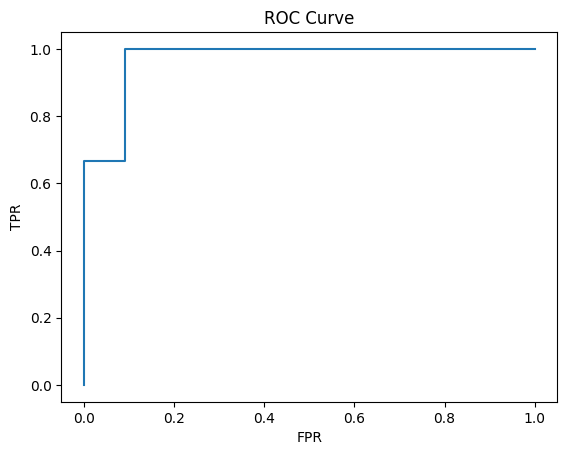

AUC: 0.9696969696969696


In [64]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.show()

print("AUC:", roc_auc_score(y_test, y_prob))

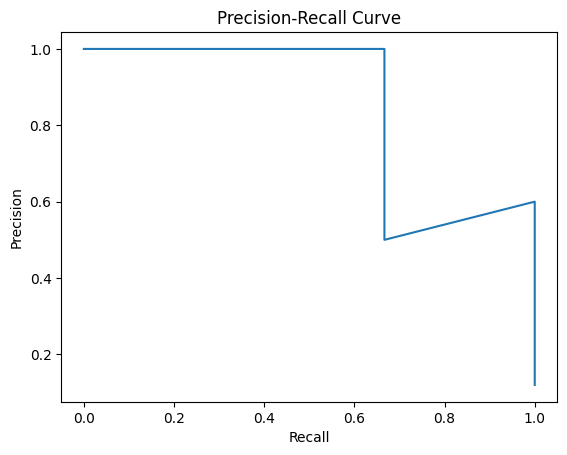

In [65]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [66]:
import numpy as np

for t in [0.3, 0.4, 0.5, 0.6]:
    y_pred_t = (y_prob >= t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_t))


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        22
           1       1.00      0.33      0.50         3

    accuracy                           0.92        25
   macro avg       0.96      0.67      0.73        25
weighted avg       0.93      0.92      0.90        25


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        22
           1       1.00      0.33      0.50         3

    accuracy                           0.92        25
   macro avg       0.96      0.67      0.73        25
weighted avg       0.93      0.92      0.90        25


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        22
           1       1.00      0.33      0.50         3

    accuracy                           0.92        25
   macro avg       0.96      0.67      0.73        25
weighted avg       0.93   

In [67]:
print(y_prob)

[0.02360122 0.02360122 0.02360122 0.02360122 0.21160321 0.99999718
 0.03978605 0.02360122 0.10809745 0.02360122 0.02360122 0.04409225
 0.02360122 0.01365628 0.02052981 0.15336216 0.22825701 0.17875553
 0.21007486 0.02360122 0.02360122 0.02360122 0.24333205 0.01766029
 0.02360122]


In [68]:
for t in [0.1, 0.2, 0.3]:
    y_pred_t = (y_prob >= t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_t))


Threshold: 0.1
              precision    recall  f1-score   support

           0       1.00      0.77      0.87        22
           1       0.38      1.00      0.55         3

    accuracy                           0.80        25
   macro avg       0.69      0.89      0.71        25
weighted avg       0.93      0.80      0.83        25


Threshold: 0.2
              precision    recall  f1-score   support

           0       1.00      0.91      0.95        22
           1       0.60      1.00      0.75         3

    accuracy                           0.92        25
   macro avg       0.80      0.95      0.85        25
weighted avg       0.95      0.92      0.93        25


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        22
           1       1.00      0.33      0.50         3

    accuracy                           0.92        25
   macro avg       0.96      0.67      0.73        25
weighted avg       0.93   

# Model Evaluation Report: Spanish White Wine Classification

## 1. Objective

The objective of this analysis is to build and evaluate a binary classification model that predicts whether a Spanish white wine is of high quality or not. The response variable is defined as a binary indicator derived from the original rating score.

---

## 2. Data Preparation

The dataset was preprocessed as follows:

- The target variable `binary_rating` was created:
  - Value 1 if rating ≥ 4.2  
  - Value 0 otherwise  

- Irrelevant variables such as `wine` and `winery` were removed.

- The variable `year` was transformed into `wine_age` using 2026 as the reference year.

- Categorical variables were converted into numerical format using one-hot encoding.

- The dataset was filtered to include only white wines.

- Constant (non-informative) features were removed.

---

## 3. Train-Test Split

The dataset was split into training and test sets:

- Training set: 98 samples  
- Test set: 25 samples  

Stratified sampling was used to preserve class proportions in both sets.

The class distribution is highly imbalanced:

- Class 0 (not high-quality): majority  
- Class 1 (high-quality): minority  

This imbalance must be considered when evaluating model performance.

---

## 4. Model and Pipeline

A machine learning pipeline was implemented with the following components:

- **Preprocessing:**
  - StandardScaler applied to continuous variables (`num_reviews`, `price`, `wine_age`)
  - Binary variables passed through without transformation

- **Model:**
  - Logistic Regression classifier

This pipeline ensures that preprocessing steps are consistently applied during both training and testing.

---

## 5. Evaluation Metrics

### 5.1 Confusion Matrix

The confusion matrix is:
[[22 0]
[ 2 1]]


Interpretation:

- 22 true negatives (correctly predicted low-quality wines)  
- 1 true positive (correctly predicted high-quality wine)  
- 2 false negatives (missed high-quality wines)  
- 0 false positives  

The model is highly conservative, producing no false positives but missing several positive cases.

---

### 5.2 Classification Report

| Class | Precision | Recall | F1-score |
|------|----------|--------|----------|
| 0    | 0.92     | 1.00   | 0.96     |
| 1    | 1.00     | 0.33   | 0.50     |

Key observations:

- The model performs very well on the majority class (class 0).
- For the minority class (class 1), recall is low (0.33), meaning most high-quality wines are not detected.
- Precision for class 1 is perfect (1.00), indicating that when the model predicts a high-quality wine, it is correct.

Accuracy is 0.92, but this is misleading due to class imbalance.

---

### 5.3 ROC Curve and AUC

The ROC curve shows strong separability between classes, with:

- AUC ≈ 0.97

This indicates that the model is capable of distinguishing between classes effectively. However, this performance is not fully reflected in classification metrics due to the default decision threshold.

---

### 5.4 Precision-Recall Curve

The precision-recall curve highlights the trade-off between detecting high-quality wines (recall) and avoiding false positives (precision). This is particularly relevant in imbalanced datasets.

---

## 6. Threshold Analysis

The default classification threshold is 0.5. However, this threshold is not optimal for this problem.

Different thresholds were tested:

### Threshold = 0.3
- Recall (class 1): 0.33  
- Precision (class 1): 1.00  
- The model is too strict and misses many high-quality wines.

### Threshold = 0.2
- Recall (class 1): 1.00  
- Precision (class 1): 0.60  
- F1-score improves significantly.

### Threshold = 0.1
- Recall (class 1): 1.00  
- Precision (class 1): 0.38  
- Too many false positives.

---

### Best Threshold

A threshold of **0.2** provides the best balance between precision and recall:

- All high-quality wines are detected (recall = 1.00)
- Precision remains acceptable (0.60)
- F1-score is maximized

This demonstrates that model performance depends not only on the model itself but also on the choice of threshold.

---

## 7. Multiclass Extension

For problems with more than two classes (e.g., "regular", "medium", "top" wines):

- The confusion matrix becomes an NxN matrix.
- Precision, recall, and F1-score are computed for each class.
- Macro and weighted averages summarize overall performance.
- ROC curves can be extended using a one-vs-rest approach.

---

## 8. Discussion on Class Imbalance

The dataset is imbalanced, with significantly fewer high-quality wines.

Implications:

- Accuracy is not a reliable metric.
- The model tends to favor the majority class.
- Metrics such as recall and F1-score for the minority class are more informative.

Adjusting the classification threshold is an effective way to improve performance in this setting.

---

## 9. Conclusion

The logistic regression model demonstrates strong discriminative ability (AUC ≈ 0.97), but its default classification performance is limited by class imbalance and threshold selection.

By lowering the classification threshold, the model significantly improves its ability to detect high-quality wines while maintaining acceptable precision.

This analysis highlights the importance of:
- Using appropriate evaluation metrics
- Considering class imbalance
- Tuning the classification threshold

These steps are essential for building reliable and interpretable machine learning models.